# ___Environmental properties___
-----------------------

In [1]:
!python --version

Python 3.13.7


The system cannot find the path specified.


In [6]:
from urllib.request import Request, urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, Patch
from bs4 import BeautifulSoup

In [44]:
with open(file=r"../../data/maps/australia-borders-coordinates.npy", mode="rb") as fp: border = np.load(fp)

# IN EMMA'S DATASET, THE SITE NAMES ARE ALL FUCKED UP!!!!!! (STATE, SITE, COORDINATES ETC.)
themeda = pd.read_csv(r"../../data/chapter3/CSBP_soil_analysis_Themeda_and_Sorghum.csv", skiprows=range(20, 35)).drop(0, axis=0)
themeda = themeda.rename(mapper= lambda name: name.lower().strip().replace(' ', '_').replace('(', '').replace(')', '').replace('%', 'prcnt'), axis=1)
themeda = themeda.astype({"total_nitrogen": np.float64, "total_phosphorus": np.float64, "total_carbon": np.float64, "prcnt_clay": np.float64, "prcnt_course_sand": np.float64, "prcnt_fine_sand": np.float64, "prcnt_sand": np.float64, "prcnt_silt": np.float64})
CHOSEN_SITES = ("TT4", "TT6", "TT7", "TT13", "TT15", "TT17")
themeda_subset = themeda.query("customer_sample_id.isin(@CHOSEN_SITES)")

meterology = pd.read_csv(r"../../data/chapter3/site_metereology.csv", header=2).drop(index=[2, 3]).reset_index(drop=True)
meterology = meterology.sort_values(by="site_code_emma", key=lambda col: col.str.replace("TT", '').astype(int))

In [11]:
for _ in themeda_subset[["latitude", "longitude"]].iterrows():
    print(_)

(4, latitude     -34.784167
longitude    138.696667
Name: 4, dtype: float64)
(6, latitude     -27.156601
longitude    151.235198
Name: 6, dtype: float64)
(7, latitude     -33.62908
longitude    151.11302
Name: 7, dtype: float64)
(13, latitude     -19.001291
longitude    145.473311
Name: 13, dtype: float64)
(15, latitude     -21.637977
longitude    116.334303
Name: 15, dtype: float64)
(17, latitude     -24.235
longitude    133.459
Name: 17, dtype: float64)


In [31]:
themeda_subset.total_phosphorus / 1e6 # total soil P content in w/w %

4     0.000091
6     0.000229
7     0.000221
13    0.000160
15    0.000157
17    0.000225
Name: total_phosphorus, dtype: float64

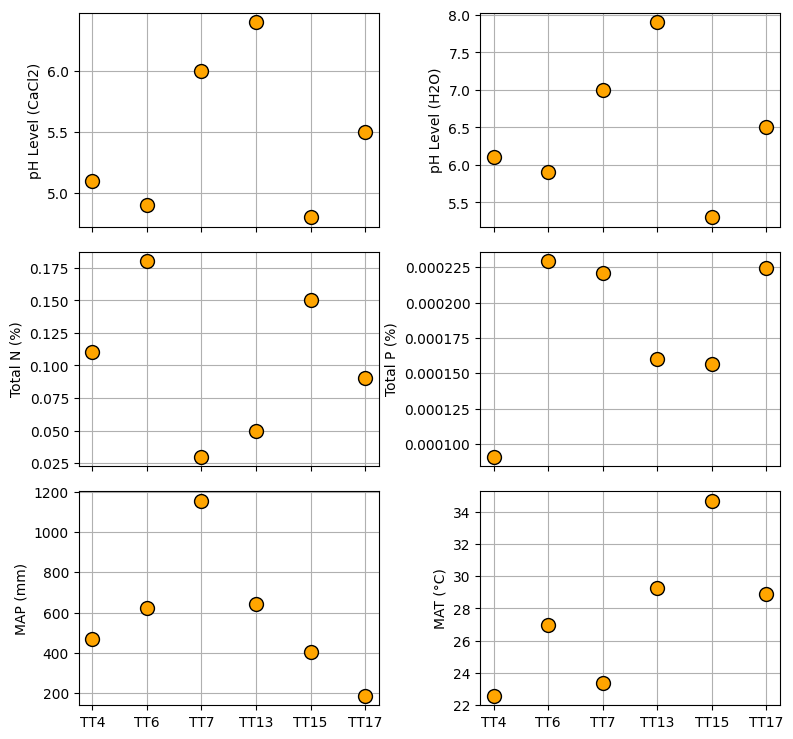

In [49]:
fig, axes = plt.subplots(nrows=3, ncols=2, sharex=True, sharey=False)
fig.set_size_inches(8, 7.5)

for (prop, name, axis) in zip(("ph_level_cacl2", "ph_level_h2o", "total_nitrogen", "total_phosphorus"), ("pH Level (CaCl2)", "pH Level (H2O)", "Total N (%)", "Total P (%)"), axes.flatten()[:4]):
    # if total_phosphorus, convert mg/kg to w/w %
    if prop == "total_phosphorus":
        axis.plot(themeda_subset.customer_sample_id, themeda_subset.total_phosphorus / 1e6, linestyle="none", marker='o', mec="black", mfc="orange", markersize=10)
    else:
        axis.plot(themeda_subset.customer_sample_id, themeda_subset[prop], linestyle="none", marker='o', mec="black", mfc="orange", markersize=10)
    axis.grid()
    axis.set_ylabel(name)

# in the bottom two grids, plot MAT and MAP
for (prop, name, axis) in zip(("annual_rainfall_mm", "mean_annual_temp_celsius"), ("MAP (mm)", "MAT (°C)"), axes.flatten()[4:]):
    axis.plot(meterology.site_code_emma, meterology[prop], linestyle="none", marker='o', mec="black", mfc="orange", markersize=10)
    axis.grid()
    axis.set_ylabel(name)

plt.tight_layout()
plt.show()
# plt.savefig(fname=r"../../plots/themeda_site_props.png", dpi=500, transparent=True)

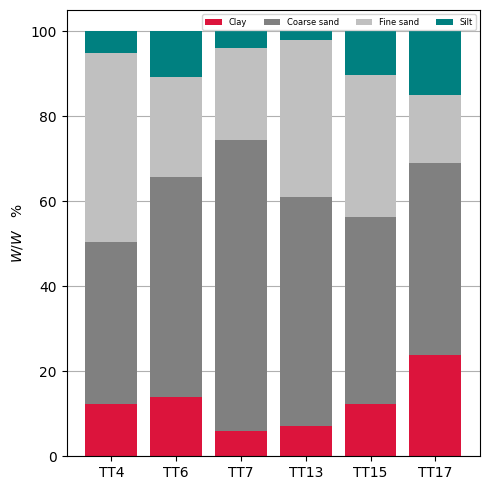

In [5]:
# SOIL TEXTURE 

fig, axes = plt.subplots()
fig.set_size_inches(5, 5)

axes.bar(x=themeda_subset.customer_sample_id, height=themeda_subset.prcnt_clay, color="crimson", label="Clay")
axes.bar(x=themeda_subset.customer_sample_id, height=themeda_subset.prcnt_course_sand, bottom=themeda_subset.prcnt_clay, color="grey", label="Coarse sand")
axes.bar(x=themeda_subset.customer_sample_id, height=themeda_subset.prcnt_fine_sand, bottom=themeda_subset.prcnt_clay+themeda_subset.prcnt_course_sand, color="silver", label="Fine sand")
axes.bar(x=themeda_subset.customer_sample_id, height=themeda_subset.prcnt_silt, bottom=themeda_subset.prcnt_clay+themeda_subset.prcnt_sand, color="teal", label="Silt")
axes.set_axisbelow(True)
axes.grid(axis='y')
axes.legend(loc="upper right", ncols=4, fontsize=6)
axes.set_ylabel(r"$W/W\hspace{1}\%$")    
plt.tight_layout()
plt.show()
# plt.savefig(fname=r"../../plots/emma_themeda_subset_soil_texture.jpeg", dpi=500)

In [10]:
themeda_subset.loc[:, ["customer_sample_id", "latitude", "longitude"]]

,customer_sample_id,latitude,longitude
4,TT4,-34.784167,138.696667
6,TT6,-27.156601,151.235198
7,TT7,-33.629080,151.113020
13,TT13,-19.001291,145.473311
15,TT15,-21.637977,116.334303
17,TT17,-24.235000,133.459000


In [11]:
themeda_seeds

,Location,latitude,longitude
0,Rainbow Valley_NT,-24.237644,133.553612
1,Panawonica_WA,-21.644900,116.323300
2,Forbes_NSW,-33.407612,147.965494
3,Hobart_TAS,-42.905670,147.323016
4,Dalby_QLD,-27.114868,151.181761
5,Virginia Gardens_SA,-34.853889,138.620556
6,Mt Fox N Park_QLD,-19.001300,145.473117
7,Sydney_NSW,-33.688102,151.062410


In [55]:
# coordinates from Emma's work and Vin's work are quite identical :)
pd.merge(left=themeda_subset, left_on="customer_sample_id", right=meterology, right_on="site_code_emma").loc[:, ["latitude_x", "longitude_x", "latitude_y", "longitude_y"]].corr()

,latitude_x,longitude_x,latitude_y,longitude_y
latitude_x,1.000000,-0.389731,0.999989,-0.387642
longitude_x,-0.389731,1.000000,-0.387944,0.999991
latitude_y,0.999989,-0.387944,1.000000,-0.385854
longitude_y,-0.387642,0.999991,-0.385854,1.000000
